# 5x1000 — Beneficiari e importi per ente

Dataset: `ade_cinque_per_mille` (Agenzia delle Entrate)

Analisi pubblica: [README](../README.md)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIGS = Path("../figures")
FIGS.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

URL = "https://storage.googleapis.com/dataciviclab-clean/ade_cinque_per_mille/2024/ade_cinque_per_mille_2024_clean.parquet"

def query(sql):
    result = con.execute(sql)
    cols = [desc[0] for desc in result.description]
    return pd.DataFrame(result.fetchall(), columns=cols)

df = query(f"SELECT * FROM read_parquet('{URL}')")
print(f"Righe: {len(df):,}, Colonne: {list(df.columns)}")

Righe: 90,611, Colonne: ['anno', 'progressivo', 'codice_fiscale', 'denominazione', 'regione', 'sigla_provincia', 'comune', 'flag_ets_onlus', 'flag_asd', 'flag_ricerca_scientifica', 'flag_ricerca_sanitaria', 'flag_comune', 'flag_beni_culturali', 'flag_area_protetta', 'numero_scelte', 'importo_scelte_espresse', 'importo_scelte_generiche', 'importo_ripartizione', 'importo_totale_erogabile']


In [2]:
# 1. Distribuzione per categoria
cat_df = query(f"""
    SELECT
        CASE
            WHEN flag_ets_onlus = true AND flag_asd = false AND flag_comune = false
                 AND flag_ricerca_scientifica = false AND flag_ricerca_sanitaria = false THEN 'ETS / ONLUS'
            WHEN flag_ets_onlus = true AND flag_ricerca_scientifica = true AND flag_ricerca_sanitaria = true
                 THEN 'ETS + Ricerca scientifica e sanitaria'
            WHEN flag_asd = true THEN 'Sportive dilettantistiche'
            WHEN flag_ricerca_scientifica = true AND flag_ricerca_sanitaria = true
                 AND flag_ets_onlus = false THEN 'Ricerca scientifica e sanitaria'
            WHEN flag_ricerca_scientifica = true AND flag_ets_onlus = false THEN 'Ricerca scientifica'
            WHEN flag_ricerca_sanitaria = true AND flag_ets_onlus = false THEN 'Ricerca sanitaria'
            WHEN flag_comune = true THEN 'Comuni'
            WHEN flag_beni_culturali = true THEN 'Beni culturali'
            WHEN flag_area_protetta = true THEN 'Aree protette'
            ELSE 'Altro'
        END AS categoria,
        COUNT(*) AS num_enti,
        ROUND(SUM(importo_totale_erogabile), 0) AS importo_totale
    FROM read_parquet('{URL}')
    GROUP BY categoria
    ORDER BY importo_totale DESC
""")
print(cat_df.to_string(index=False))

                            categoria  num_enti  importo_totale
                          ETS / ONLUS     68122     309453479.0
ETS + Ricerca scientifica e sanitaria        10      95763007.0
                    Ricerca sanitaria        79      34805225.0
      Ricerca scientifica e sanitaria        14      20512256.0
                                Altro        57      18509175.0
            Sportive dilettantistiche     13826      18321036.0
                               Comuni      7909      15278492.0
                  Ricerca scientifica       386       8319453.0
                       Beni culturali       187        595508.0
                        Aree protette        21        405607.0


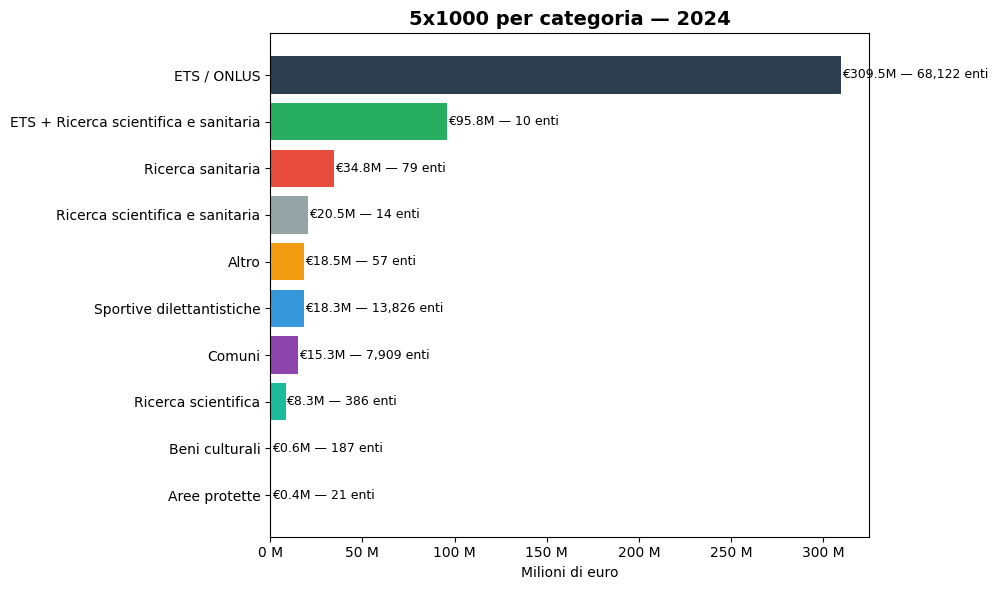

In [3]:
palette = ['#2c3e50', '#27ae60', '#e74c3c', '#95a5a6', '#f39c12', '#3498db', '#8e44ad', '#1abc9c', '#d35400', '#7f8c8d']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_df['categoria'], cat_df['importo_totale'] / 1e6, color=palette[:len(cat_df)])
ax.set_xlabel('Milioni di euro')
ax.set_title('5x1000 per categoria — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val, enti in zip(bars, cat_df['importo_totale'] / 1e6, cat_df['num_enti']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M — {enti:,} enti', va='center', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_categorie.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# 2. Importi per regione
reg_df = query(f"""
    SELECT regione,
           COUNT(*) AS num_enti,
           ROUND(SUM(importo_totale_erogabile), 0) AS importo_totale
    FROM read_parquet('{URL}')
    WHERE regione IS NOT NULL
    GROUP BY regione
    ORDER BY importo_totale DESC
""")

# Unifica Trentino
trentino_mask = reg_df['regione'].str.contains('TRENTINO', na=False)
trentino_row = reg_df[trentino_mask].sum(numeric_only=True)
reg_df = reg_df[~trentino_mask]
reg_df = pd.concat([
    reg_df,
    pd.DataFrame([{
        'regione': 'TRENTINO-ALTO ADIGE',
        'num_enti': int(trentino_row['num_enti']),
        'importo_totale': trentino_row['importo_totale']
    }])
], ignore_index=True)
reg_df = reg_df.sort_values('importo_totale', ascending=False)

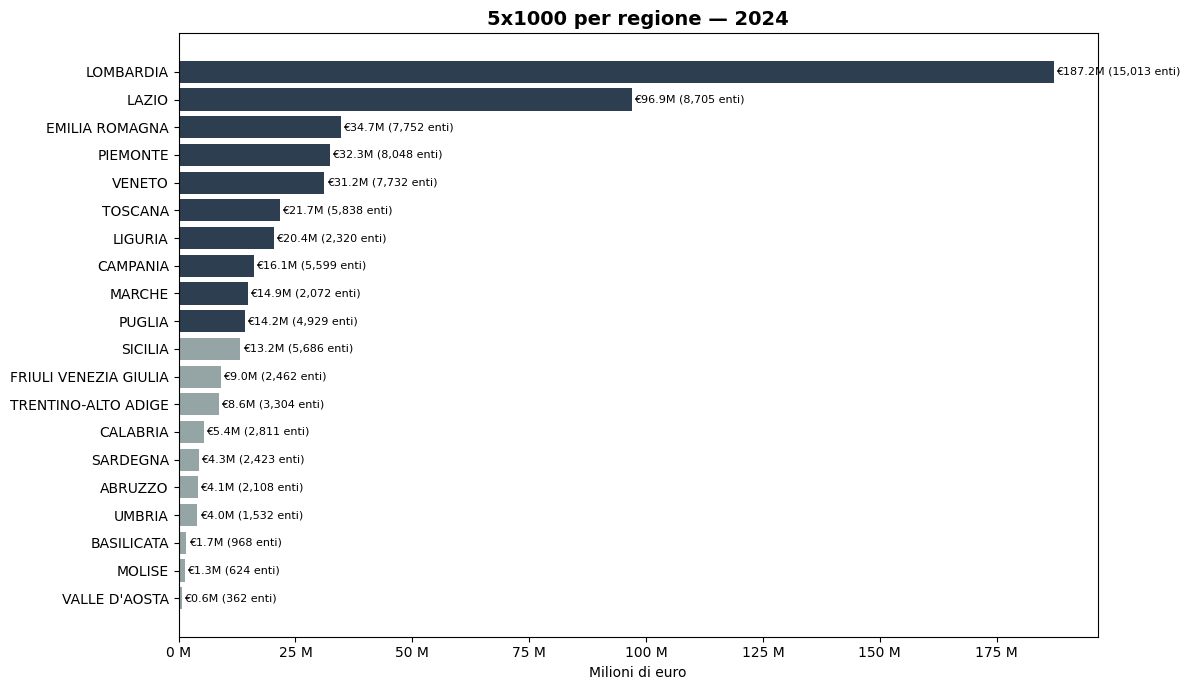

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_reg = ['#2c3e50' if v >= reg_df['importo_totale'].median() else '#95a5a6' for v in reg_df['importo_totale']]
bars = ax.barh(reg_df['regione'], reg_df['importo_totale'] / 1e6, color=colors_reg)
ax.set_xlabel('Milioni di euro')
ax.set_title('5x1000 per regione — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val, enti in zip(bars, reg_df['importo_totale'] / 1e6, reg_df['num_enti']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M ({enti:,} enti)', va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_regioni.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3. Fasce di importo (solo ETS/ONLUS)
ets_df = df[(df['flag_ets_onlus'] == True) & (df['flag_asd'] == False) & (df['flag_comune'] == False)].copy()

bins = [0, 1000, 10000, 50000, 100000, 500000, 1000000, float('inf')]
labels_fasce = ['0-1k', '1k-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '>1M']
ets_df['fascia'] = pd.cut(ets_df['importo_totale_erogabile'], bins=bins, labels=labels_fasce, right=False)

fascia_groups = ets_df.groupby('fascia', observed=False).agg(
    num_enti=('codice_fiscale', 'count'),
    importo_totale=('importo_totale_erogabile', 'sum')
).reset_index()

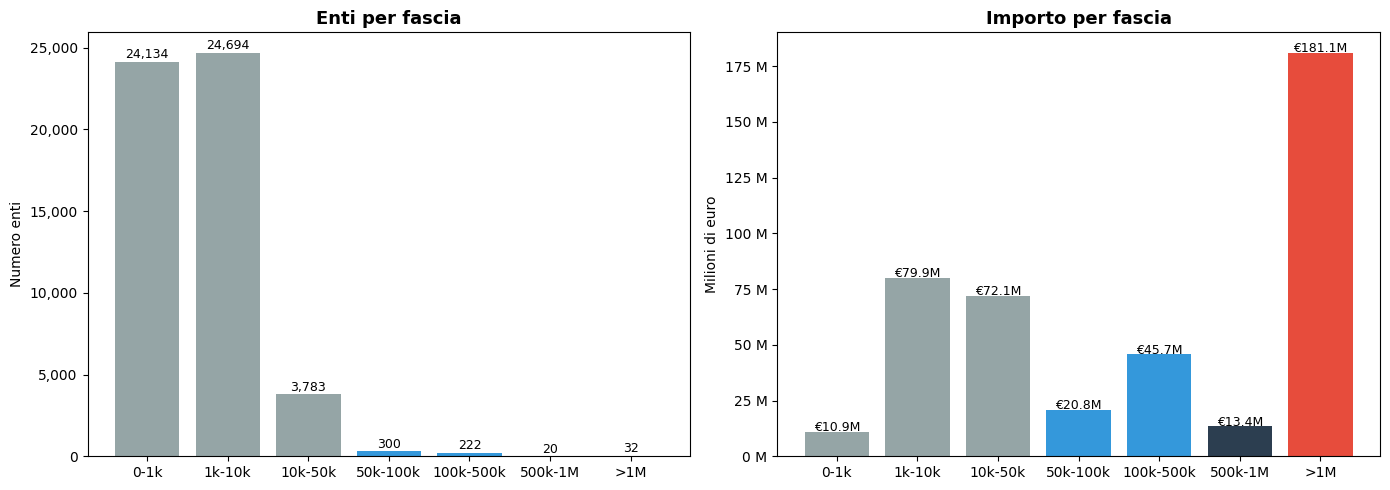

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_fasce = ['#95a5a6', '#95a5a6', '#95a5a6', '#3498db', '#3498db', '#2c3e50', '#e74c3c']

bars1 = ax1.bar(range(len(fascia_groups)), fascia_groups['num_enti'], color=colors_fasce)
ax1.set_xticks(range(len(fascia_groups)))
ax1.set_xticklabels(labels_fasce)
ax1.set_title('Enti per fascia', fontsize=13, fontweight='bold')
ax1.set_ylabel('Numero enti')
for bar, val in zip(bars1, fascia_groups['num_enti']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)

bars2 = ax2.bar(range(len(fascia_groups)), fascia_groups['importo_totale'] / 1e6, color=colors_fasce)
ax2.set_xticks(range(len(fascia_groups)))
ax2.set_xticklabels(labels_fasce)
ax2.set_title('Importo per fascia', fontsize=13, fontweight='bold')
ax2.set_ylabel('Milioni di euro')
for bar, val in zip(bars2, fascia_groups['importo_totale'] / 1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'€{val:.1f}M', ha='center', fontsize=9)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_fasce.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 4. Verifica totali
totali = query(f"""
    SELECT COUNT(*) AS num_enti,
           SUM(numero_scelte) AS tot_scelte,
           ROUND(SUM(importo_totale_erogabile), 0) AS importo_totale
    FROM read_parquet('{URL}')
""")
print(f"Enti: {totali['num_enti'].values[0]:,}")
print(f"Scelte: {totali['tot_scelte'].values[0]:,}")
print(f"Importo totale: €{totali['importo_totale'].values[0]/1e6:.1f}M")

Enti: 90,611
Scelte: 15,145,758
Importo totale: €522.0M


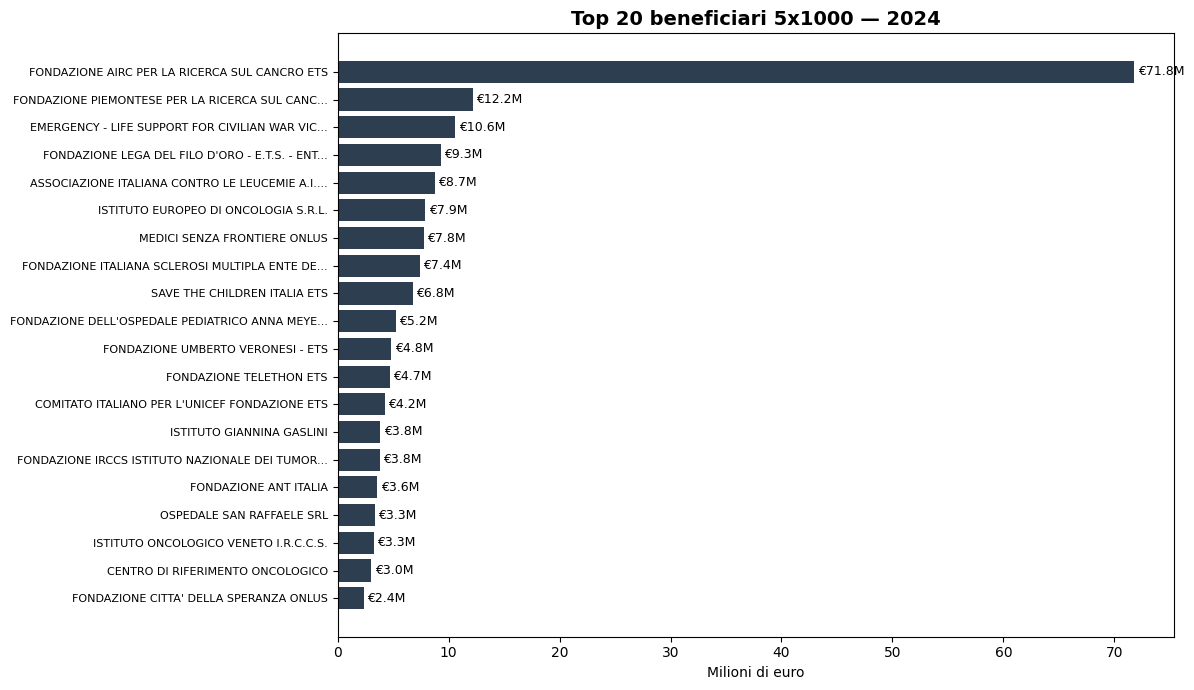

Figure generate: [PosixPath('../figures/cinque-per-mille_regioni.png'), PosixPath('../figures/cinque-per-mille_fasce.png'), PosixPath('../figures/cinque-per-mille_top20.png'), PosixPath('../figures/cinque-per-mille_categorie.png')]


In [9]:
# 5. Top 20 enti
top20 = query(f"""
    SELECT denominazione, regione, numero_scelte,
           ROUND(importo_totale_erogabile, 0) AS importo_totale
    FROM read_parquet('{URL}')
    ORDER BY importo_totale_erogabile DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
yticks = range(len(top20))
labels_top = [f"{d[:45]}..." if len(d) > 45 else d for d in top20['denominazione']]
bars = ax.barh(yticks, top20['importo_totale'] / 1e6, color='#2c3e50')
ax.set_yticks(yticks)
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Milioni di euro')
ax.set_title('Top 20 beneficiari 5x1000 — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top20['importo_totale'] / 1e6):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure generate:", list(FIGS.glob('*.png')))